In [ ]:
#scikit-learnをマスターを進める

In [1]:
import numpy as np
import pandas as pd
df=pd.DataFrame(
    {
        'A':[1,np.nan,3,4,5],
        'B':[6,7,8,np.nan,10],
        'C':[11,12,13,14,15]
    }
)
df

,A,B,C
0,1.0,6.0,11
1,NaN,7.0,12
2,3.0,8.0,13
3,4.0,NaN,14
4,5.0,10.0,15


In [2]:
df.isnull()

,A,B,C
0,False,False,False
1,True,False,False
2,False,False,False
3,False,True,False
4,False,False,False


In [3]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='mean')
imp.fit(df)
imp.transform(df)

array([[ 1.  ,  6.  , 11.  ],
       [ 3.25,  7.  , 12.  ],
       [ 3.  ,  8.  , 13.  ],
       [ 4.  ,  7.75, 14.  ],
       [ 5.  , 10.  , 15.  ]])

In [4]:
df=pd.DataFrame(
    {
        'A':[1,2,3,4,5],
        'B':['a','b','a','b','c']
    }
)
df

,A,B
0,1,a
1,2,b
2,3,a
3,4,b
4,5,c


In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(df.loc[:,'B'])#ラベルのエンコーディング　a,b,cをそれぞれ数値に変換する
le.transform(df.loc[:,'B'])

array([0, 1, 0, 1, 2])

In [6]:
le.classes_

array(['a', 'b', 'c'], dtype=object)

In [7]:
df

,A,B
0,1,a
1,2,b
2,3,a
3,4,b
4,5,c


In [9]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
df_ohe=df.copy()#もとのdfを壊さないためにコピーを使用する
le=LabelEncoder()
df_ohe.loc[:,'B']=le.fit_transform(df_ohe.loc[:,'B'])   #さっきやったラベルのエンコーディング
ohe=ColumnTransformer(                                  #columntranformerは列ごとに異なる変換をまとめて適応できるクラス
    [('OneHotEncoder',OneHotEncoder(),[1])],            #(名前、変換機、対象列)
                      remainder='passthrough'
)
df_ohe=ohe.fit_transform(df_ohe)
df_ohe

array([[1., 0., 0., 1.],
       [0., 1., 0., 2.],
       [1., 0., 0., 3.],
       [0., 1., 0., 4.],
       [0., 0., 1., 5.]])

In [11]:
df=pd.DataFrame(
    {'A':[1,2,3,4,5],
     'B':[100,200,400,500,800]
    }
)
df

,A,B
0,1,100
1,2,200
2,3,400
3,4,500
4,5,800


In [13]:
from sklearn.preprocessing import StandardScaler
stdsc=StandardScaler()
stdsc.fit_transform(df)

array([[-1.41421356, -1.22474487],
       [-0.70710678, -0.81649658],
       [ 0.        ,  0.        ],
       [ 0.70710678,  0.40824829],
       [ 1.41421356,  1.63299316]])

In [14]:
df

,A,B
0,1,100
1,2,200
2,3,400
3,4,500
4,5,800


In [15]:
from sklearn.preprocessing import MinMaxScaler
mmsc=MinMaxScaler()
mmsc.fit(df)
mmsc.transform(df)

array([[0.        , 0.        ],
       [0.25      , 0.14285714],
       [0.5       , 0.42857143],
       [0.75      , 0.57142857],
       [1.        , 1.        ]])

In [16]:
from sklearn.datasets import load_iris

iris=load_iris()
X,y = iris.data,iris.target
print('X:')
print(X[:5,:])
print('y:')
print(y[:5])

X:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
y:
[0 0 0 0 0]


In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=123)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(105, 4)
(45, 4)
(105,)
(45,)


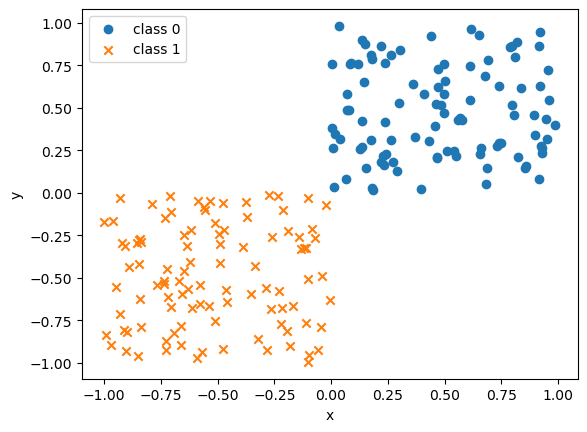

In [23]:
import numpy as np
import matplotlib.pyplot as plt

rng=np.random.default_rng(123)
x0=rng.uniform(size=(100,2))#x,y軸ともに0から１までの一様分布100点をサンプリング クラス０
y0=np.repeat(0,100)#クラス０のラベルを100個作成
x1=rng.uniform(-1.0,0.0,size=(100,2))#クラス１も
y1=np.repeat(1,100)
fig,ax=plt.subplots()
ax.scatter(x0[:,0],x0[:,1],marker='o',label='class 0')
ax.scatter(x1[:,0],x1[:,1],marker='x',label='class 1')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

In [29]:
from sklearn.svm import SVC
#学習、決定境界、マージン、サポートベクタを可視化する関数
def plot_boundary_margin_sv(x0,y0,x1,y1,kernel,C,xmin=-1,xmax=1,ymin=-1,ymax=1):
    #サポートベクタのインスタンス化
    svc=SVC(kernel=kernel,C=C)
    #学習
    svc.fit(np.vstack((x0,x1)),np.hstack((y0,y1)))

    fig,ax=plt.subplots()
    ax.scatter(x0[:,0],x0[:,1],marker='o',label='class 0')
    ax.scatter(x1[:,0],x1[:,1],marker='x',label='class 1')
    #決定境界とマージンをプロット
    xx,yy=np.meshgrid(np.linspace(xmin,xmax,100),np.linspace(ymin,ymax,100))
    xy=np.vstack([xx.ravel(),yy.ravel()]).T
    p=svc.decision_function(xy).reshape((100,100))
    ax.contour(xx,yy,p,colors='k',levels=[-1,0,1],alpha=0.5,linestyles=['--','-','--'])
    #サポートベクタのプロット
    ax.scatter(svc.support_vectors_[:,0],svc.support_vectors_[:,1],s=250,facecolors='none',edgecolors='black')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(loc='best')
    plt.show()   

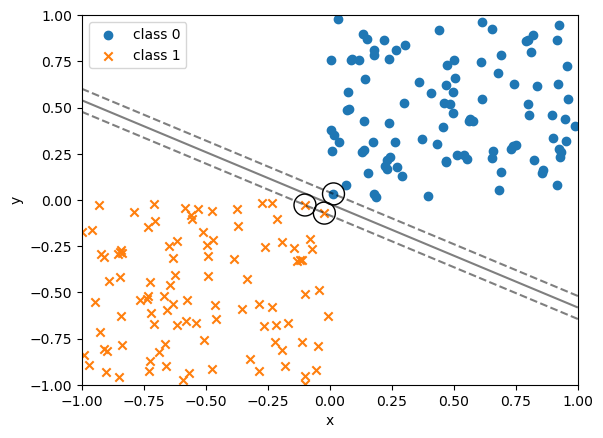

In [30]:
plot_boundary_margin_sv(x0,y0,x1,y1,kernel='linear',C=1e6)

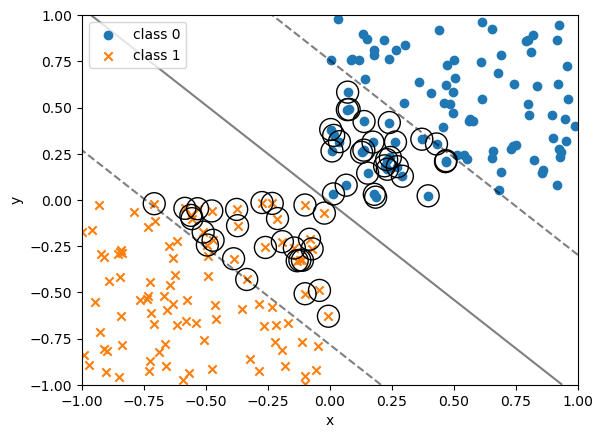

In [32]:
plot_boundary_margin_sv(x0,y0,x1,y1,kernel='linear',C=0.1)

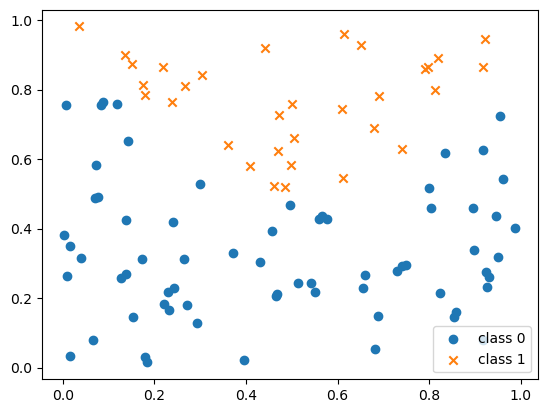

In [34]:
rng=np.random.default_rng(123)
x=rng.random(size=(100,2))
y=(x[:,1]>2*(x[:,0]-0.5)**2 + 0.5).astype(int)
fig,ax=plt.subplots()
ax.scatter(x[y==0,0],x[y==0,1],
           marker='o',label='class 0')
ax.scatter(x[y==1,0],x[y==1,1],
           marker='x',label='class 1')
ax.legend(loc='best')
plt.show()


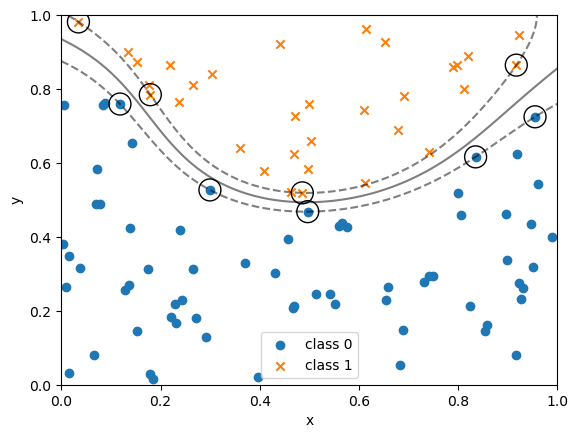

In [35]:
x0,x1=x[y==0,:],x[y==1,:]
y0,y1=y[y==0],y[y==1]
plot_boundary_margin_sv(x0,y0,x1,y1,kernel='rbf',C=1e3,xmin=0,ymin=0)

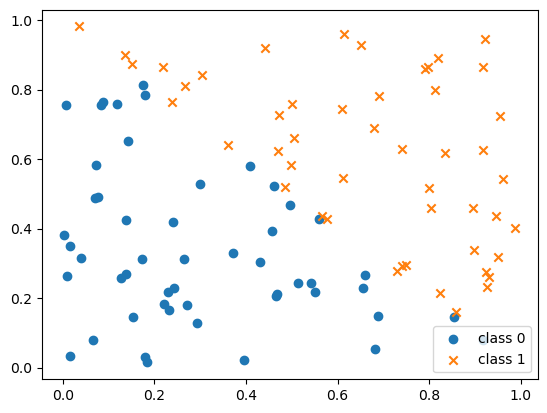

In [38]:
rng=np.random.default_rng(123)
x=rng.random(size=(100,2))
y=(x[:,1]>-x[:,0]+1.0).astype(int)
fig,ax=plt.subplots()
ax.scatter(x[y==0,0],x[y==0,1],marker='o',label='class 0')
ax.scatter(x[y==1,0],x[y==1,1],marker='x',label='class 1')
ax.legend(loc='best')
plt.show()

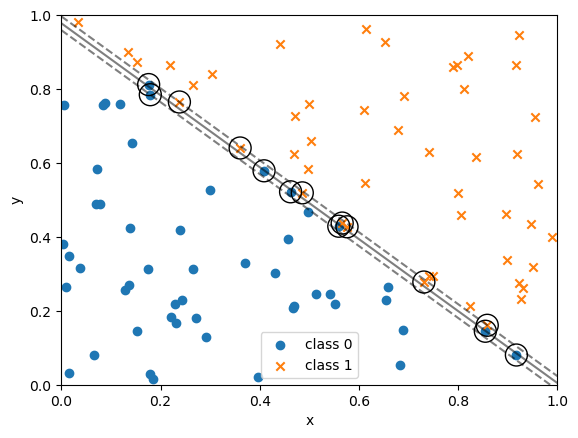

In [39]:
x0,x1=x[y==0,:],x[y==1,:]
y0,y1=y[y==0],y[y==1]
plot_boundary_margin_sv(x0,y0,x1,y1,kernel='linear',C=1e3,xmin=0,ymin=0)

In [41]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
#irisのデータを読み込む
iris=load_iris()
x,y=iris.data,iris.target     #説明変数と目的変数
#学習データセットとテストデータセットに分割する　　この前やったやつ
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=123)
#決定木をインスタンス化　木の深さは３
tree = DecisionTreeClassifier(max_depth=3,random_state=123)
#学習
tree.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
from pydotplus import graph_from_dot_data
from sklearn.tree import export_graphviz
#dot形式のデータを抽出
dot_data=export_graphviz(tree,filled=True,rounded=True,
                         class_names=['Setosa','Versicolor','Virginica'],
                         feature_names=['Sepal Length','Sepal Width','Petal Length','Petal Width'],
                         out_file=None)
#決定木のプロットを出力
grath=grath_from_dot_data(dot_data)
grath.write_png('tree.png')

ModuleNotFoundError: No module named 'pydotplus'

In [43]:
!pip install pydotplus

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24659 sha256=c02852dff91ea2ca1fd96fe05162410b38f3b41996f46f9b09439b7fa428de35
  Stored in directory: c:\users\shige\appdata\local\pip\cache\wheels\4a\c0\ed\a9eeeb08c3c53bb90d3822cf76557c8fdcbc349ee11a011169
Successfully built pydotplus


In [50]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"


from pydotplus import graph_from_dot_data
from sklearn.tree import export_graphviz
#dot形式のデータを抽出
dot_data=export_graphviz(tree,filled=True,rounded=True,
                         class_names=['Setosa','Versicolor','Virginica'],
                         feature_names=['Sepal Length','Sepal Width','Petal Length','Petal Width'],
                         out_file=None)
#決定木のプロットを出力
graph=graph_from_dot_data(dot_data)
graph.write_png('tree.png')

True

In [51]:
y_pred=tree.predict(x_test)
y_pred

array([1, 2, 2, 1, 0, 1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 1,
       0, 2, 0, 0, 0, 2, 2, 0, 2, 1, 0, 0, 1, 1, 2, 0, 0, 1, 1, 0, 2, 2,
       2])

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

#データセットを読み込む
housing=fetch_california_housing()
x,y=housing.data,housing.target
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.3,random_state=123)
#線形回帰をインスタンス化
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
x_test.shape

(6192, 8)

In [55]:
y_pred=lr.predict(x_test)

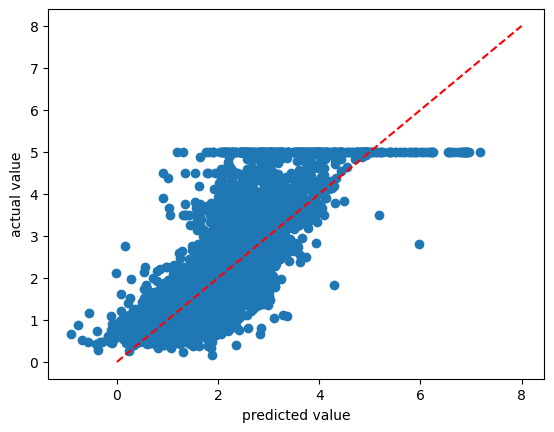

In [58]:
import matplotlib.pyplot as plt
#横軸を予測値、縦軸を実績値とする散布図
fig,ax=plt.subplots()
ax.scatter(y_pred,y_test)
ax.plot((0,8),(0,8),linestyle='dashed',color='red')
ax.set_xlabel('predicted value')
ax.set_ylabel('actual value')
plt.show()